In [ ]:
import pandas as pd

df = pd.read_csv('/content/CCD_Sales_Data_90_Days_Approx.xlsx - CCD_Sales_Data_90_Days (1).csv')

summary_stats = {
    'Measure': ['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Total (90 days)'],
    'Quantity Sold': [
        df['Qty'].mean(),
        df['Qty'].median(),
        df['Qty'].std(),
        df['Qty'].min(),
        df['Qty'].max(),
        df['Qty'].sum()
    ],
    'Net Sales (₹)': [
        df['Net Sales (INR)'].mean(),
        df['Net Sales (INR)'].median(),
        df['Net Sales (INR)'].std(),
        df['Net Sales (INR)'].min(),
        df['Net Sales (INR)'].max(),
        df['Net Sales (INR)'].sum()
    ]
}

summary_df = pd.DataFrame(summary_stats)
print(summary_df)



           Measure  Quantity Sold  Net Sales (₹)
0             Mean       6.386973   5.231062e+02
1           Median       3.000000   2.706667e+02
2          Std Dev      11.239309   5.842242e+02
3              Min       1.000000   1.000000e+01
4              Max      99.000000   3.395432e+03
5  Total (90 days)   50010.000000   4.095922e+06


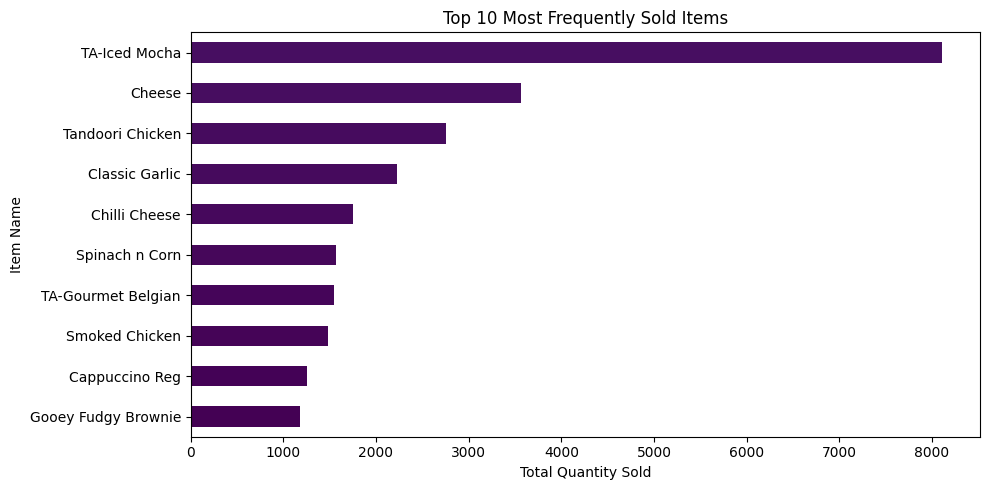

In [ ]:
import matplotlib.pyplot as plt

df = pd.read_csv('/content/CCD_Sales_Data_90_Days_Approx.xlsx - CCD_Sales_Data_90_Days (1).csv')

# Group by item and sum the quantity sold
top_items = df.groupby('Item Name')['Qty'].sum().sort_values(ascending=False).head(10)

# Plotting
plt.figure(figsize=(10, 5))
top_items.plot(kind='barh', color=plt.cm.viridis(range(10))[::-1])
plt.xlabel('Total Quantity Sold')
plt.ylabel('Item Name')
plt.title('Top 10 Most Frequently Sold Items')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

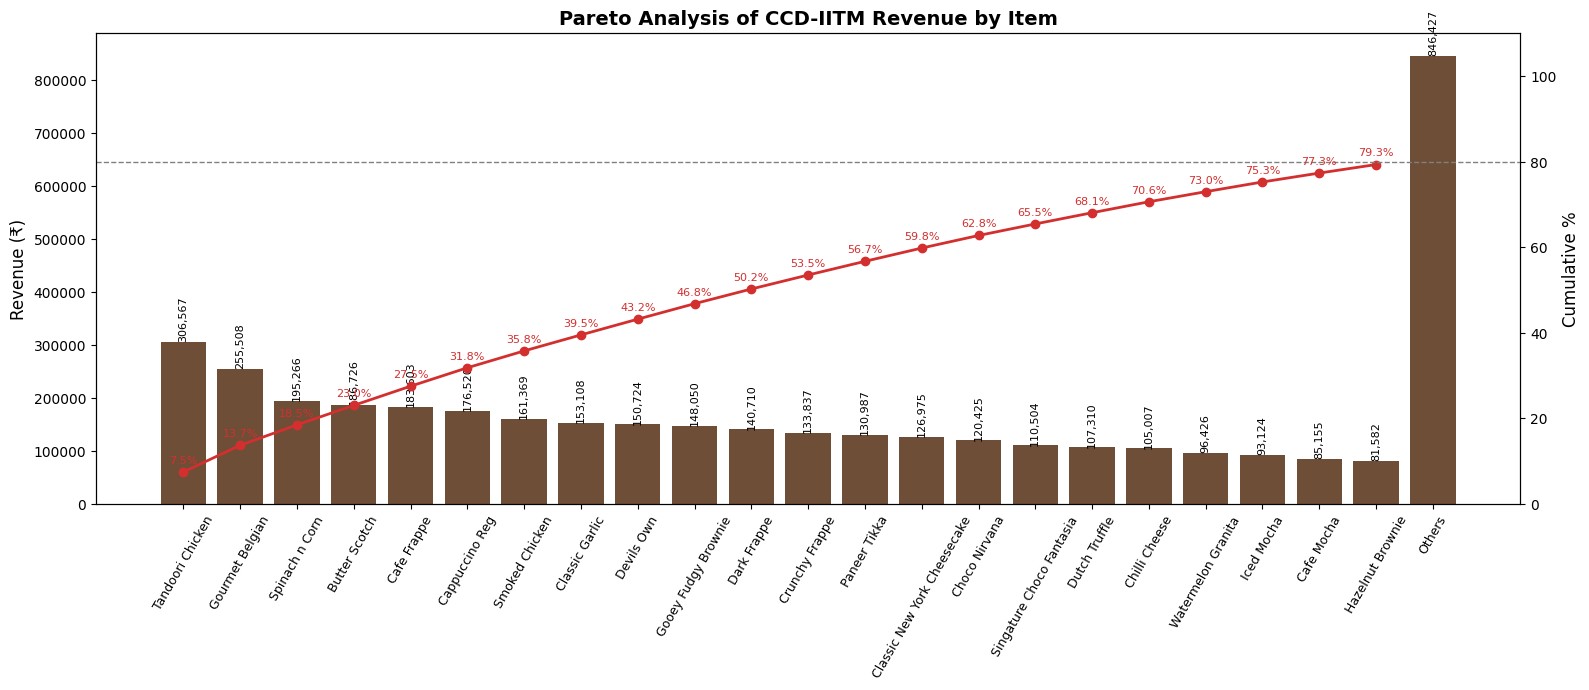

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/CCD_Sales_Data_90_Days_Approx.xlsx - CCD_Sales_Data_90_Days (1).csv")
# Step 1: Clean item names
df["Item Name"] = df["Item Name"].str.replace(r"^TA- ?", "", regex=True).str.strip()

# Step 2: Aggregate revenue by item
item_revenue = df.groupby("Item Name")["Net Sales (INR)"].sum().reset_index()

# Step 3: Sort by revenue and calculate cumulative %
item_revenue = item_revenue.sort_values(by="Net Sales (INR)", ascending=False).reset_index(drop=True)
item_revenue["Cumulative %"] = item_revenue["Net Sales (INR)"].cumsum() / item_revenue["Net Sales (INR)"].sum() * 100

# Step 4: Identify all items up to 80% cutoff
pareto_items = item_revenue[item_revenue["Cumulative %"] <= 80].copy()

# Add "Others" as the remainder
others_revenue = item_revenue.loc[pareto_items.shape[0]:, "Net Sales (INR)"].sum()
pareto_df = pd.concat([
    pareto_items,
    pd.DataFrame({"Item Name": ["Others"], "Net Sales (INR)": [others_revenue], "Cumulative %": [100.0]})
], ignore_index=True)

# Step 5: Plot
# Plot
fig, ax1 = plt.subplots(figsize=(16,7))   # wider figure for more x-axis space

# Bars for revenue
bars = ax1.bar(pareto_df["Item Name"], pareto_df["Net Sales (INR)"], color="#6F4E37")  # Coffee brown
ax1.set_ylabel("Revenue (₹)", fontsize=12)

# Rotate and shrink x-axis labels for readability
ax1.tick_params(axis="x", rotation=60, labelsize=9)

# Add revenue labels above bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height, f"{int(height):,}",
             ha="center", va="bottom", fontsize=8, rotation=90)

# Cumulative % line (exclude "Others")
ax2 = ax1.twinx()
ax2.plot(pareto_items["Item Name"], pareto_items["Cumulative %"],
         color="#D32F2F", marker="o", linewidth=2)
ax2.set_ylabel("Cumulative %", fontsize=12)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylim(0, 110)

# Labels for cumulative %
for i, val in enumerate(pareto_items["Cumulative %"]):
    ax2.text(i, val+2, f"{val:.1f}%", color="#D32F2F", ha="center", fontsize=8)

plt.title("Pareto Analysis of CCD-IITM Revenue by Item", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()



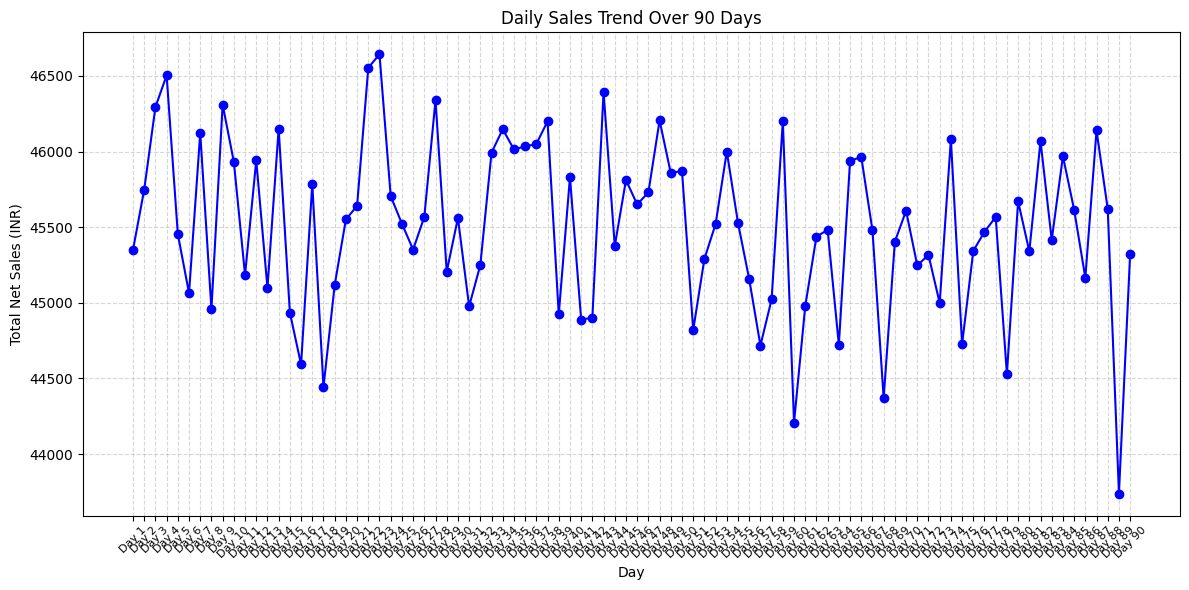

In [ ]:
df = pd.read_csv('/content/CCD_Sales_Data_90_Days_Approx.xlsx - CCD_Sales_Data_90_Days (1).csv')

# Ensuring date is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Group by date to get daily total sales
daily_sales = df.groupby('Date')['Net Sales (INR)'].sum().reset_index()
daily_sales['Day'] = ['Day ' + str(i+1) for i in range(len(daily_sales))]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(daily_sales['Day'], daily_sales['Net Sales (INR)'], color='blue', marker='o')
plt.title('Daily Sales Trend Over 90 Days')
plt.xlabel('Day')
plt.ylabel('Total Net Sales (INR)')
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Correlation: 0.10


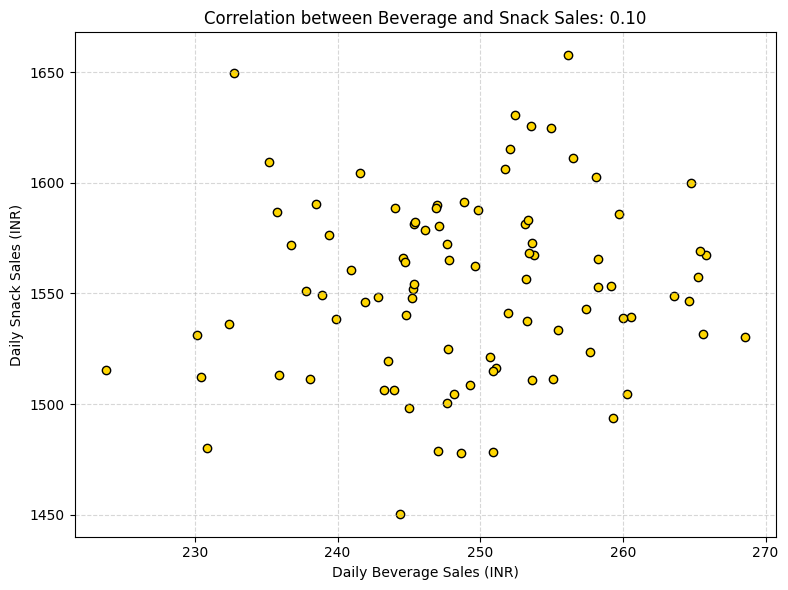

In [ ]:
from scipy.stats import pearsonr

np.random.seed(42)
x = np.random.normal(250, 10, 90)


def find_corr(x, _corr, noise_std=50, base=1550, max_iter=1000):
    for _ in range(max_iter):
        noise = np.random.normal(0, noise_std, len(x))
        scale = _corr * (np.std(noise) / np.std(x))
        y = scale * (x - np.mean(x)) + base + noise
        corr = np.corrcoef(x, y)[0, 1]
        if abs(corr - _corr) < 0.01:
            return y, corr
    return y, corr


y, corr = find_corr(x, _corr=0.10)


df = pd.DataFrame({
    'Date': pd.date_range(start='2024-08-23', periods=90, freq='D'),
    'Beverage': x,
    'Snack': y
})

# Display correlation
print(f"Correlation: {corr:.2f}")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(df['Beverage'], df['Snack'], color='gold', edgecolors='black')
plt.title(f'Correlation between Beverage and Snack Sales: {corr:.2f}')
plt.xlabel('Daily Beverage Sales (INR)')
plt.ylabel('Daily Snack Sales (INR)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


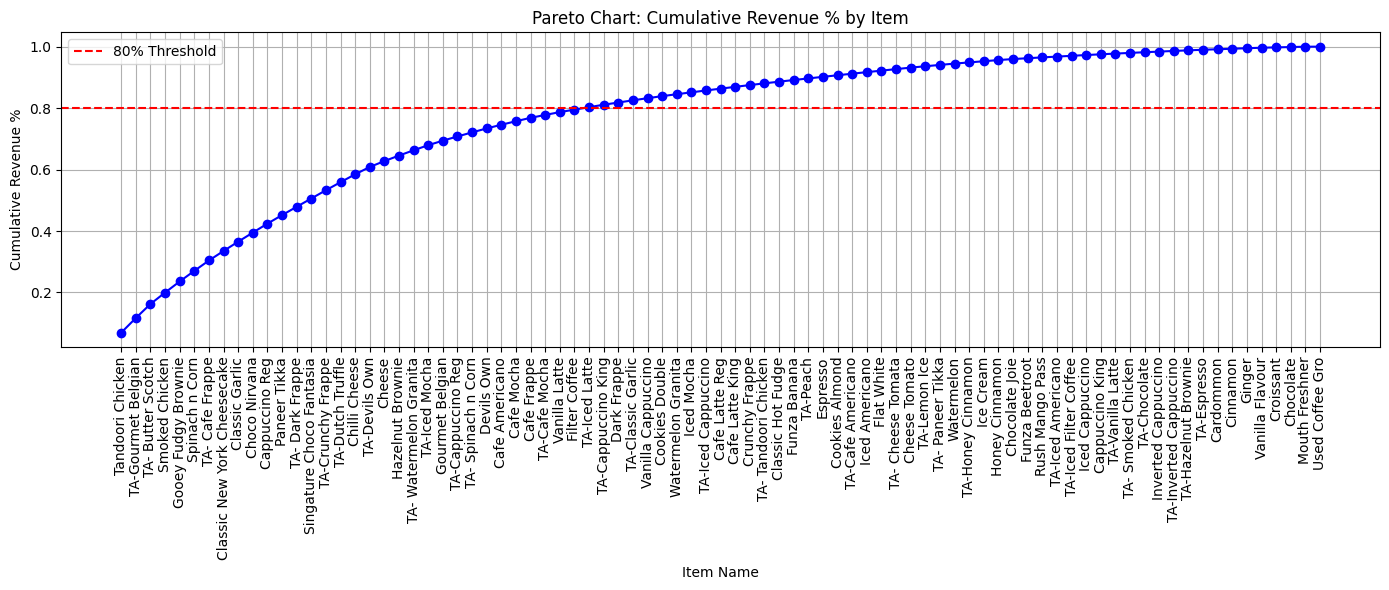

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV (rename if your file name differs)
df = pd.read_csv("CCD_Sales_Data_90_Days_Approx.xlsx - CCD_Sales_Data_90_Days (1).csv")

# Group by 'Item Name' and sum 'Net Sales'
item_sales = df.groupby('Item Name')['Net Sales (INR)'].sum().sort_values(ascending=False)

# Compute cumulative revenue percentage
cumulative_sales = item_sales.cumsum()
cumulative_percentage = cumulative_sales / item_sales.sum()

# Plot Pareto Chart
plt.figure(figsize=(14, 6))
plt.plot(cumulative_percentage.values, marker='o', linestyle='-', color='blue')
plt.xticks(range(len(item_sales)), item_sales.index, rotation=90)
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Threshold')
plt.xlabel("Item Name")
plt.ylabel("Cumulative Revenue %")
plt.title("Pareto Chart: Cumulative Revenue % by Item")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
df = pd.read_csv("/content/CCD_Sales_Data_90_Days_Approx.xlsx - CCD_Sales_Data_90_Days (1).csv")

print(df.columns.tolist())

['Date', 'Category', 'Sub-category', 'Item Name', 'Qty', 'Net Sales (INR)']


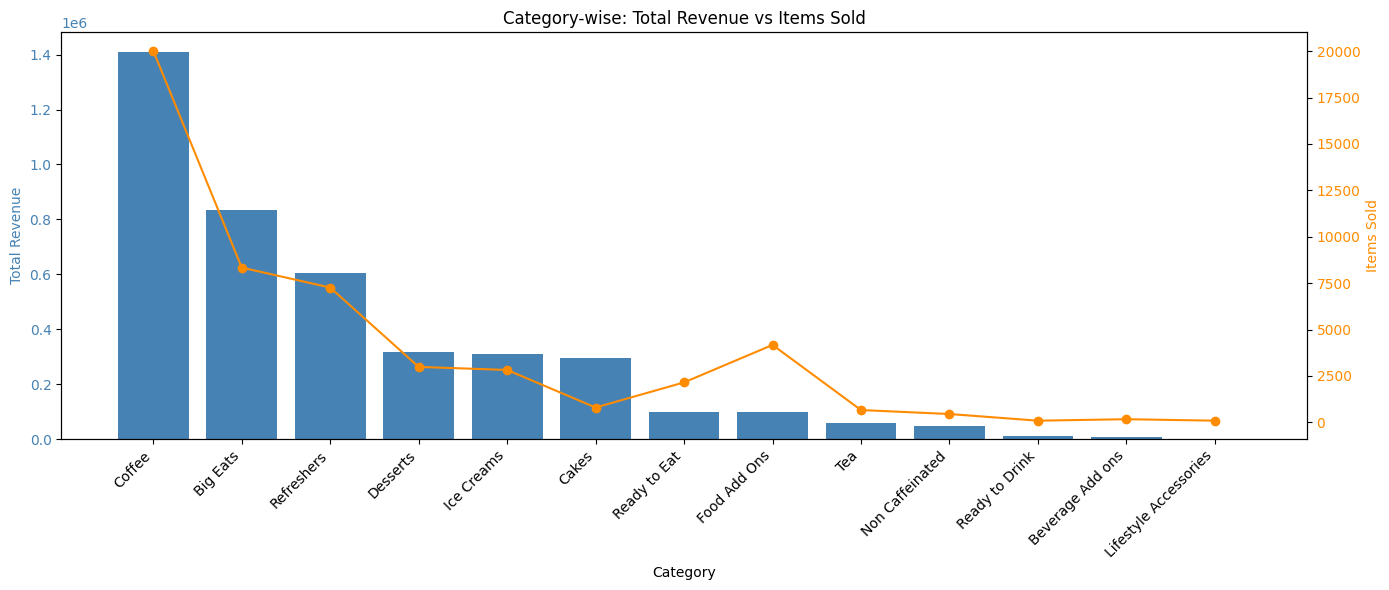

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = "/content/CCD_Sales_Data_Cleaned_v2.csv"
df = pd.read_csv(file_path)

# Adjust these column names as per your actual data
category_col = 'Category'
qty_col = 'Qty'
sales_col = 'Net Sales (INR)'
# Group by Category
category_summary = df.groupby(category_col).agg(
    Total_Revenue=(sales_col, 'sum'),
    Items_Sold=(qty_col, 'sum')
).reset_index()

# Sort by Total Revenue for consistent bar ordering
category_summary = category_summary.sort_values(by='Total_Revenue', ascending=False)

# Plotting
fig, ax1 = plt.subplots(figsize=(14, 6))  # wider for better label spacing

# Bar chart for Total Revenue
ax1.bar(category_summary[category_col], category_summary['Total_Revenue'], color='steelblue')
ax1.set_ylabel('Total Revenue', color='steelblue')
ax1.set_xlabel('Category')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_title('Category-wise: Total Revenue vs Items Sold')

# Line chart for Items Sold
ax2 = ax1.twinx()
ax2.plot(category_summary[category_col], category_summary['Items_Sold'], color='darkorange', marker='o')
ax2.set_ylabel('Items Sold', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Ensure all x-axis labels are shown properly
ax1.set_xticks(range(len(category_summary[category_col])))
ax1.set_xticklabels(category_summary[category_col], rotation=45, ha='right')

plt.tight_layout()
plt.show()



 Inventory Items to Increase for Next Month:

           Item Name  Predicted Qty Next Month  Current Inventory  \
71     TA-Iced Mocha               2762.338029              400.0   
8             Cheese               1213.770771              200.0   
76  Tandoori Chicken                930.000000              180.0   
15    Classic Garlic                754.285714              150.0   
10     Chilli Cheese                595.714286              140.0   

    Need to Increase    Best Model       MAE  MAPE (%)  R2 Score Confidence  
71       2362.338029  Holt-Winters  4.754230  5.244966  0.128638       High  
8        1013.770771  Holt-Winters  1.935356  4.844775 -0.076963       High  
76        750.000000           SMA  1.428571  4.720920  0.000000       High  
15        604.285714           SMA  0.775510  3.059015  0.000000       High  
10        455.714286           SMA  0.775510  3.979421  0.000000       High  


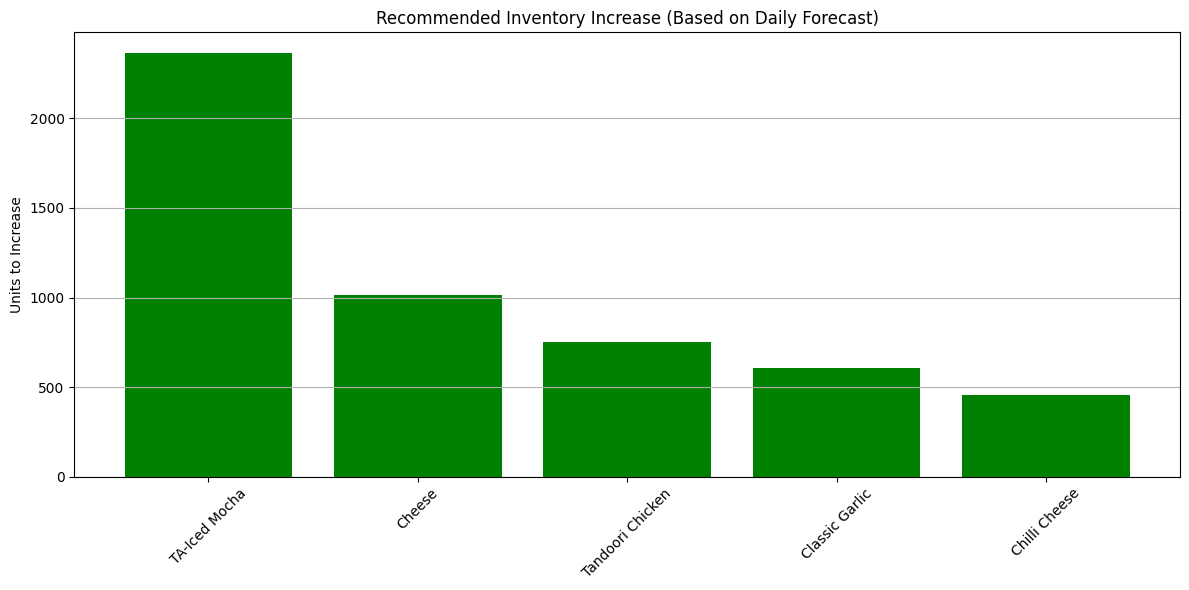

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, r2_score

# Load data
df = pd.read_csv("/content/CCD_Sales_Data_Cleaned_v2.csv")
df['Date'] = pd.to_datetime(df['Date'])

# Group daily sales
daily_sales = df.groupby(['Date', 'Item Name'])['Qty'].sum().reset_index()
pivot = daily_sales.pivot(index='Date', columns='Item Name', values='Qty').fillna(0)

# Inventory info
inventory_info = {
    'TA-Iced Mocha': 400,
    'Cheese': 200,
    'Tandoori Chicken': 180,
    'Classic Garlic': 150,
    'Chilli Cheese': 140,
    'Choco Fantasia': 160,
    'Croissants': 100,
    'Coffee Beans': 20 * 300,
    'Water Bottles': 12 * 7,
}
inventory_df = pd.DataFrame(list(inventory_info.items()), columns=['Item Name', 'Current Inventory'])

# Forecasting
predictions = []
for item in pivot.columns:
    y = pivot[item].values
    if len(y) < 14:  # need at least 2 weeks
        continue

    # ---- Holt-Winters ----
    try:
        model_hw = ExponentialSmoothing(y, trend='add', seasonal='add', seasonal_periods=7).fit()
        fitted_hw = model_hw.fittedvalues
        forecast_hw = model_hw.forecast(30)
        mae_hw = mean_absolute_error(y[-30:], fitted_hw[-30:]) if len(y) > 30 else mean_absolute_error(y, fitted_hw)
        mape_hw = np.mean(np.abs((y[-30:] - fitted_hw[-30:]) / (y[-30:] + 1e-8))) * 100 if len(y) > 30 else np.mean(np.abs((y - fitted_hw) / (y + 1e-8))) * 100
        r2_hw = r2_score(y[-30:], fitted_hw[-30:]) if len(y) > 30 else r2_score(y, fitted_hw)
        total_hw = forecast_hw.sum()
    except Exception as e:
        mae_hw, mape_hw, r2_hw, total_hw = np.inf, np.inf, -np.inf, 0

    # ---- Simple Moving Average (last 7 days) ----
    sma_forecast = np.repeat(np.mean(y[-7:]), 30)
    total_sma = sma_forecast.sum()
    fitted_sma = np.concatenate([np.repeat(np.nan, len(y)-7), np.repeat(np.mean(y[-7:]), 7)])
    mae_sma = mean_absolute_error(y[-7:], fitted_sma[-7:])
    mape_sma = np.mean(np.abs((y[-7:] - fitted_sma[-7:]) / (y[-7:] + 1e-8))) * 100
    r2_sma = r2_score(y[-7:], fitted_sma[-7:])

    # ---- Pick Best ----
    if mae_hw < mae_sma:
        best_model, total_next_month, mae, mape, r2 = "Holt-Winters", total_hw, mae_hw, mape_hw, r2_hw
    else:
        best_model, total_next_month, mae, mape, r2 = "SMA", total_sma, mae_sma, mape_sma, r2_sma

    predictions.append({
        'Item Name': item,
        'Predicted Qty Next Month': total_next_month,
        'Best Model': best_model,
        'MAE': mae,
        'MAPE (%)': mape,
        'R2 Score': r2
    })

# Create forecast DataFrame
forecast_df = pd.DataFrame(predictions)

# Merge with inventory
merged = pd.merge(forecast_df, inventory_df, on='Item Name', how='left')
merged['Need to Increase'] = merged['Predicted Qty Next Month'] - merged['Current Inventory']

# Confidence flag
def confidence_flag(mape):
    if mape < 20:
        return "High"
    elif mape < 40:
        return "Medium"
    else:
        return "Low"

merged['Confidence'] = merged['MAPE (%)'].apply(confidence_flag)

# Recommendations
recommendations = merged[merged['Need to Increase'] > 0].sort_values('Need to Increase', ascending=False)

# ---- Results ----
print("\n Inventory Items to Increase for Next Month:\n")
print(recommendations[['Item Name','Predicted Qty Next Month','Current Inventory','Need to Increase','Best Model','MAE','MAPE (%)','R2 Score','Confidence']])

# ---- Visualization ----
plt.figure(figsize=(12, 6))
plt.bar(recommendations['Item Name'], recommendations['Need to Increase'], color='green')
plt.xticks(rotation=45)
plt.ylabel('Units to Increase')
plt.title('Recommended Inventory Increase (Based on Daily Forecast)')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


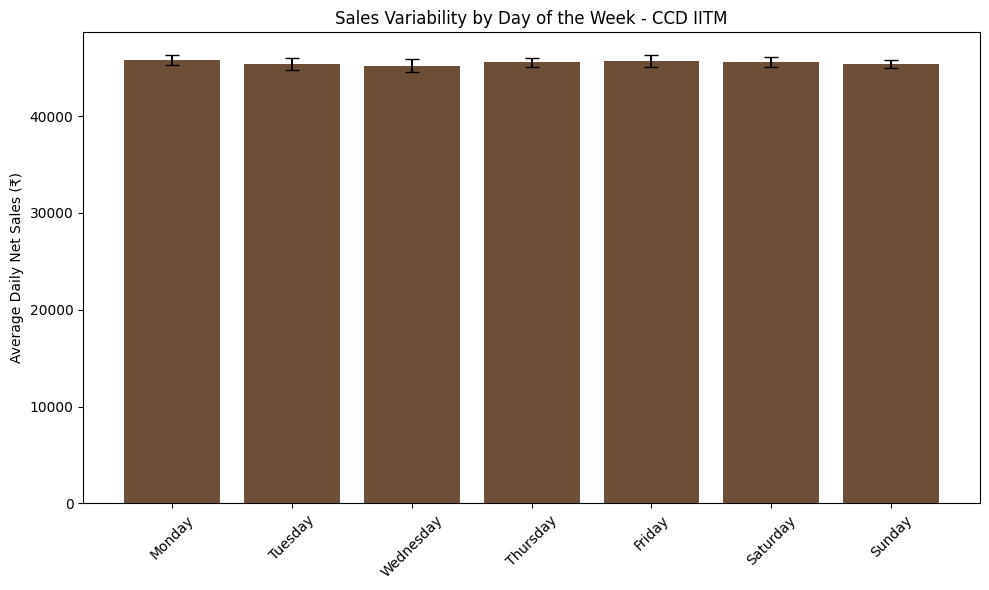

Average sales and variability by weekday:
   DayOfWeek          mean         std  count
1     Monday  45814.763735  525.282443     13
5    Tuesday  45362.331457  617.777637     13
6  Wednesday  45219.019330  657.616586     13
4   Thursday  45555.623004  446.071172     13
0     Friday  45675.101331  600.194037     12
2   Saturday  45588.850072  538.565031     13
3     Sunday  45368.692564  424.554093     13


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/CCD_Sales_Data_90_Days_Approx.xlsx - CCD_Sales_Data_90_Days (1).csv")  # update file name if needed

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Extract day of week (0 = Monday, 6 = Sunday)
df["DayOfWeek"] = df["Date"].dt.day_name()

# Aggregate total daily sales
daily_sales = df.groupby(["Date"])["Net Sales (INR)"].sum().reset_index()

# Add weekday name
daily_sales["DayOfWeek"] = daily_sales["Date"].dt.day_name()

# Average sales per weekday
weekday_avg = daily_sales.groupby("DayOfWeek")["Net Sales (INR)"].agg(["mean", "std", "count"]).reset_index()

# Order weekdays properly
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_avg["DayOfWeek"] = pd.Categorical(weekday_avg["DayOfWeek"], categories=weekday_order, ordered=True)
weekday_avg = weekday_avg.sort_values("DayOfWeek")

# Plot bar chart with error bars (mean ± std)
plt.figure(figsize=(10,6))
plt.bar(weekday_avg["DayOfWeek"], weekday_avg["mean"], yerr=weekday_avg["std"], capsize=5, color="#6F4E37")
plt.ylabel("Average Daily Net Sales (₹)")
plt.title("Sales Variability by Day of the Week - CCD IITM")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print stats for report
print("Average sales and variability by weekday:")
print(weekday_avg)


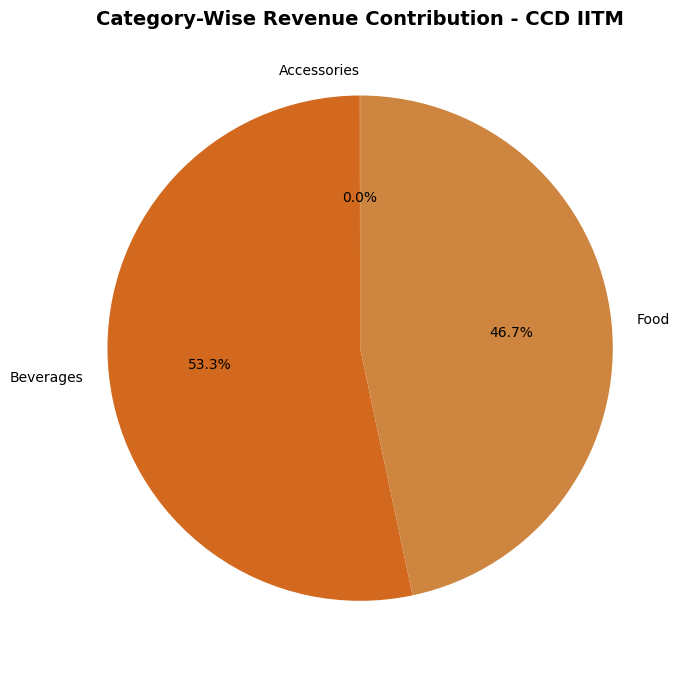

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("CCD_Sales_Data_Cleaned_v2.csv")

# Map categories into Food / Beverages / Accessories
food_cats = ["Big Eats", "Cakes", "Desserts", "Food Add Ons", "Ready To Eat", "Ice Creams"]
beverage_cats = ["Coffee", "Tea", "Refreshers", "Non Caffeinated", "Ready To Drink", "Beverage Add Ons"]

def classify_category(cat):
    if cat in food_cats:
        return "Food"
    elif cat in beverage_cats:
        return "Beverages"
    elif cat == "Lifestyle Accessories":
        return "Accessories"
    else:
        return "Unknown"

df["Broad Category"] = df["Category"].apply(classify_category)

# Group by broad category
broad_revenue = df.groupby("Broad Category")["Net Sales (INR)"].sum().reset_index()

# Only keep Food, Beverages, Accessories
broad_revenue = broad_revenue[broad_revenue["Broad Category"].isin(["Food", "Beverages", "Accessories"])]

# Pie chart
plt.figure(figsize=(7,7))
plt.pie(broad_revenue["Net Sales (INR)"],
        labels=broad_revenue["Broad Category"],
        autopct="%1.1f%%",
        startangle=90,
        colors=["#8B4513", "#D2691E", "#CD853F"])  # Coffee tones
plt.title("Category-Wise Revenue Contribution - CCD IITM", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()
